# Phase 6 — Classical control: the baseline to beat

Before training an RL agent we need a **reference**: a conventional controller built with
textbook methods. It serves three purposes:

1. a **benchmark** — an RL agent is only interesting if it matches or beats it;
2. a proof that each RL task is **feasible** with the given reward;
3. an **inner loop** for hierarchical RL: the agent can command load factor and roll rate, and a
   fly-by-wire system turns those into control-surface deflections.

Layers, from the inside out:

```
 autopilot:  altitude ─► vertical speed ─► flight-path angle ─► n_z ┐
             heading  ─► bank angle μ ─────────────────► roll rate ├─► fly-by-wire ─► δe, δa, δr, throttle
             airspeed ─────────────────────────────────► throttle ┘      (inner loop)
```

Code: `src/jetsim/control/` — `pid.py`, `fbw.py`, `autopilot.py`, `lqr.py`, `maneuvers.py`.

In [1]:
%matplotlib inline
import math

import matplotlib.pyplot as plt
import numpy as np

from jetsim.aircraft import dynamics_3dof as d3
from jetsim.aircraft import dynamics_6dof as d6
from jetsim.aircraft.instruments import read_instruments
from jetsim.aircraft.params import load_aircraft
from jetsim.control import maneuvers
from jetsim.control.autopilot import Autopilot, AutopilotTargets
from jetsim.control.fbw import FbwGains, HighLevelCommand, make_inner_loop
from jetsim.control.lqr import LongitudinalLQR
from jetsim.control.pid import PID
from jetsim.viz.style import GRID, INK, INK_2, SERIES, apply_style

apply_style()
plt.rcParams["figure.dpi"] = 110
DEG = math.pi / 180
params = load_aircraft("f16")
DT = 0.02  # control loop at 50 Hz (2 physics steps)

## 1. The PID building block

$$u = K_p\,e + K_i \int e\,dt - K_d\,\frac{dy}{dt}, \qquad e = y_{ref} - y$$

The project's `PID` adds three practical features that matter a lot in flight control:

* **derivative on the measurement** (not on the error): no spike when the set-point jumps;
* **anti-windup**: the integrator freezes while the output is saturated and the error pushes
  further into saturation;
* **bumpless transfer**: `reset(output=...)` preloads the integrator so that engaging the
  autopilot in flight does not jolt the controls.

Anti-windup in action, on a toy first-order plant $\dot y = (u - y)/2$ with an actuator limited
to $|u| \le 1$:

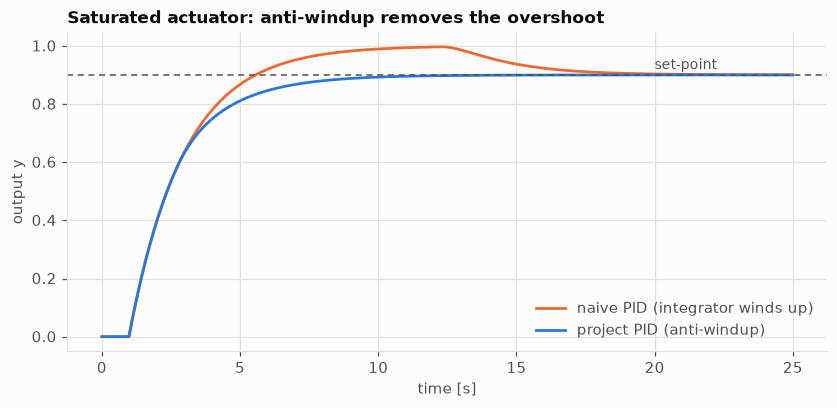

In [2]:
def run_pid(anti_windup: bool, t_end=25.0, dt=0.02):
    kp, ki = 3.0, 1.5
    pid = PID(kp, ki, out_min=-1.0, out_max=1.0)
    y, integral, ys = 0.0, 0.0, []
    for k in range(int(t_end / dt)):
        ref = 0.9 if k * dt >= 1.0 else 0.0
        e = ref - y
        if anti_windup:
            u = pid(e, dt)
        else:  # naive PID: integrates no matter what, then clips
            integral += e * dt
            u = min(max(kp * e + ki * integral, -1.0), 1.0)
        y += dt * (u - y) / 2.0
        ys.append(y)
    return np.arange(len(ys)) * dt, np.array(ys)


fig, ax = plt.subplots(figsize=(7.5, 3.6), layout="constrained")
for aw, color, label in (
    (False, SERIES[1], "naive PID (integrator winds up)"),
    (True, SERIES[0], "project PID (anti-windup)"),
):
    tt, yy = run_pid(aw)
    ax.plot(tt, yy, color=color, label=label)
ax.axhline(0.9, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
ax.text(20, 0.92, "set-point", color=INK_2, fontsize=9)
ax.set_xlabel("time [s]"), ax.set_ylabel("output y")
ax.set_title("Saturated actuator: anti-windup removes the overshoot")
ax.legend(loc="lower right")
plt.show()

## 2. Fly-by-wire: the inner loop

The fly-by-wire (FBW) system takes a **high-level command** — load factor $n_z$, roll rate $p$,
throttle — and computes surface deflections at 50 Hz. This `HighLevelCommand` is the common
language of every controller in the project, *including the hierarchical RL agent*.

**Pitch** — PI on the load-factor error plus pitch-rate damping, with gains scaled by the
dynamic pressure (at low $\bar q$ the same deflection produces less force, so gains grow):

$$\delta_e = -\Big[\sigma\big(K_{n}\,e_{n_z} + K_{i}\!\int e_{n_z}\big) - K_q\,\sigma^{0.5}\,q\Big],
  \qquad \sigma = \operatorname{clip}\!\left(\frac{\bar q_{ref}}{\bar q}, 0.3, 3\right)$$

**Roll** — PI on the roll-rate error. **Yaw** — drive sideslip to zero, plus a *yaw damper* on
the high-pass filtered yaw rate (to damp the Dutch roll without fighting the steady yaw rate of
a turn). **Protections** — the $n_z$ command is limited to [−3, +9] g, rate-limited to 20 g/s, and
reduced whenever α approaches 25°: the aircraft cannot be over-stressed or stalled.

reference dynamic pressure 18 kPa, n_z limits [-3.0, 9.0] g, α limit 25°, n_z slew 20 g/s


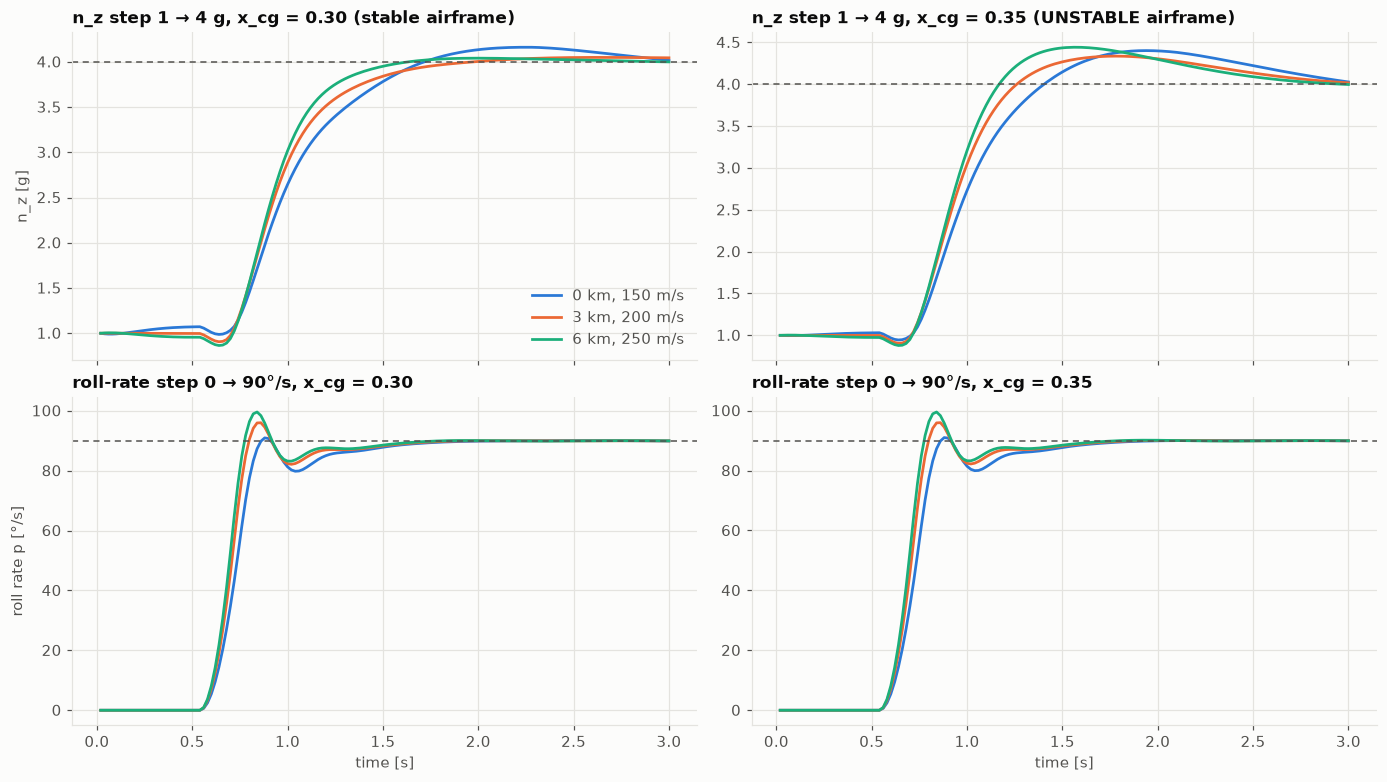

In [3]:
g = FbwGains()
print(
    f"reference dynamic pressure {g.q_ref / 1000:.0f} kPa, n_z limits [{g.nz_min}, {g.nz_max}] g, "
    f"α limit {g.alpha_max / DEG:.0f}°, n_z slew {g.nz_slew_rate:.0f} g/s"
)


def fbw_step_response(xcg, h, v, command, t_end=3.0):
    model = d6.F16SixDof(params, xcg=xcg)
    x, u0 = model.trim(h, v)
    loop = make_inner_loop(model)
    loop.reset(x)
    t, out = 0.0, []
    while t < t_end:
        ins = read_instruments(model, x)
        u = loop(ins, command(t, u0[d6.THROTTLE]), DT)
        for _ in range(2):
            x = model.step(x, u)
        t = round(t + DT, 9)
        out.append((t, ins.nz, ins.p / DEG, ins.beta / DEG))
    return np.array(out)


def nz_step(t, thr):
    return HighLevelCommand(nz=4.0 if t > 0.5 else 1.0, roll_rate=0.0, throttle=thr)


def p_step(t, thr):
    return HighLevelCommand(nz=1.0, roll_rate=90 * DEG if t > 0.5 else 0.0, throttle=thr)


points = [(0, 150), (3000, 200), (6000, 250)]
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7), layout="constrained", sharex=True)
for col, xcg in enumerate((0.30, 0.35)):
    for (h, v), color in zip(points, SERIES, strict=True):
        label = f"{h / 1000:.0f} km, {v} m/s"
        r = fbw_step_response(xcg, h, v, nz_step)
        axes[0, col].plot(r[:, 0], r[:, 1], color=color, label=label)
        r = fbw_step_response(xcg, h, v, p_step)
        axes[1, col].plot(r[:, 0], r[:, 2], color=color, label=label)
    kind = "stable airframe" if xcg < 0.33 else "UNSTABLE airframe"
    axes[0, col].set_title(f"n_z step 1 → 4 g, x_cg = {xcg:.2f} ({kind})")
    axes[1, col].set_title(f"roll-rate step 0 → 90°/s, x_cg = {xcg:.2f}")
    axes[0, col].axhline(4, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
    axes[1, col].axhline(90, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
    axes[1, col].set_xlabel("time [s]")
axes[0, 0].set_ylabel("n_z [g]"), axes[1, 0].set_ylabel("roll rate p [°/s]")
axes[0, 0].legend(loc="lower right")
plt.show()

The gains were tuned by systematic search in simulation over 0–9 km and 150–300 m/s: 1 → 4 g in
0.4–0.9 s, 90°/s of roll in 0.2–0.3 s with less than 1° of sideslip. The response is nearly the
same across flight conditions (thanks to gain scheduling) **and across CG positions**: the FBW
makes the unstable $x_{cg} = 0.35$ airframe fly like the stable one — exactly what the real F-16
computer does.

The same point, more directly: an unstable F-16 ($x_{cg} = 0.40$) disturbed by a 2° angle-of-
attack gust, with the controls frozen versus with the FBW holding 1 g:

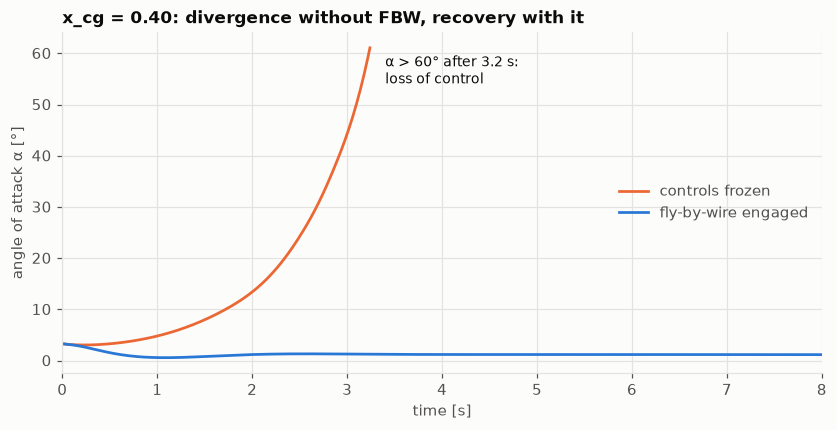

In [4]:
model = d6.F16SixDof(params, xcg=0.40)
fig, ax = plt.subplots(figsize=(7.5, 3.8), layout="constrained")
for with_fbw, color, label in (
    (False, SERIES[1], "controls frozen"),
    (True, SERIES[0], "fly-by-wire engaged"),
):
    x, u0 = model.trim(3000, 200)
    x[d6.W] += 200 * 2 * DEG  # vertical gust: +2° of angle of attack
    loop = make_inner_loop(model)
    loop.reset(x)
    t, hist = 0.0, []
    while t < 8.0:
        ins = read_instruments(model, x)
        u = loop(ins, HighLevelCommand(1.0, 0.0, u0[0]), DT) if with_fbw else u0
        for _ in range(2):
            x = model.step(x, u)
        t = round(t + DT, 9)
        hist.append((t, ins.alpha / DEG))
        if ins.alpha > 60 * DEG:  # departed from controlled flight: stop plotting
            break
    hist = np.array(hist)
    ax.plot(hist[:, 0], hist[:, 1], color=color, label=label)
    if not with_fbw:
        ax.annotate(
            f"α > 60° after {hist[-1, 0]:.1f} s:\nloss of control",
            hist[-1],
            xytext=(10, -4),
            textcoords="offset points",
            ha="left",
            va="top",
            color=INK,
            fontsize=9,
        )
ax.set_xlim(0, 8)
ax.set_xlabel("time [s]"), ax.set_ylabel("angle of attack α [°]")
ax.set_title("x_cg = 0.40: divergence without FBW, recovery with it")
ax.legend(loc="center right")
plt.show()

## 3. The autopilot: outer loops

The autopilot turns *targets* (altitude, heading, speed, or an imposed bank angle) into a
`HighLevelCommand`, using cascaded loops:

* **vertical**: $\dot h_{cmd} = K_h(h_{ref} - h)$ (clipped at ±40 m/s),
  $\gamma_{cmd} = \arcsin(\dot h_{cmd}/V)$, then a PI gives a flight-path-rate correction:
  $$n_z = \frac{\cos\gamma}{\cos\mu} + \frac{V}{g}\,\dot\gamma_{cmd}$$
  The first term is what holds the flight path in a banked turn (1 g level, 2 g at 60° of bank);
* **lateral**: heading error → desired turn rate → bank $\mu_{cmd} = \arctan(\omega V/g)$ (≤ 60°)
  → PI → roll rate;
* **speed**: PI on airspeed → throttle.

The **same gains** are used for both aircraft models. Here both fly the same mission: climb to
4000 m heading east at 230 m/s, then a level 4 g turn at 250 m/s (bank imposed), then back
north, descending to 3000 m at 200 m/s.

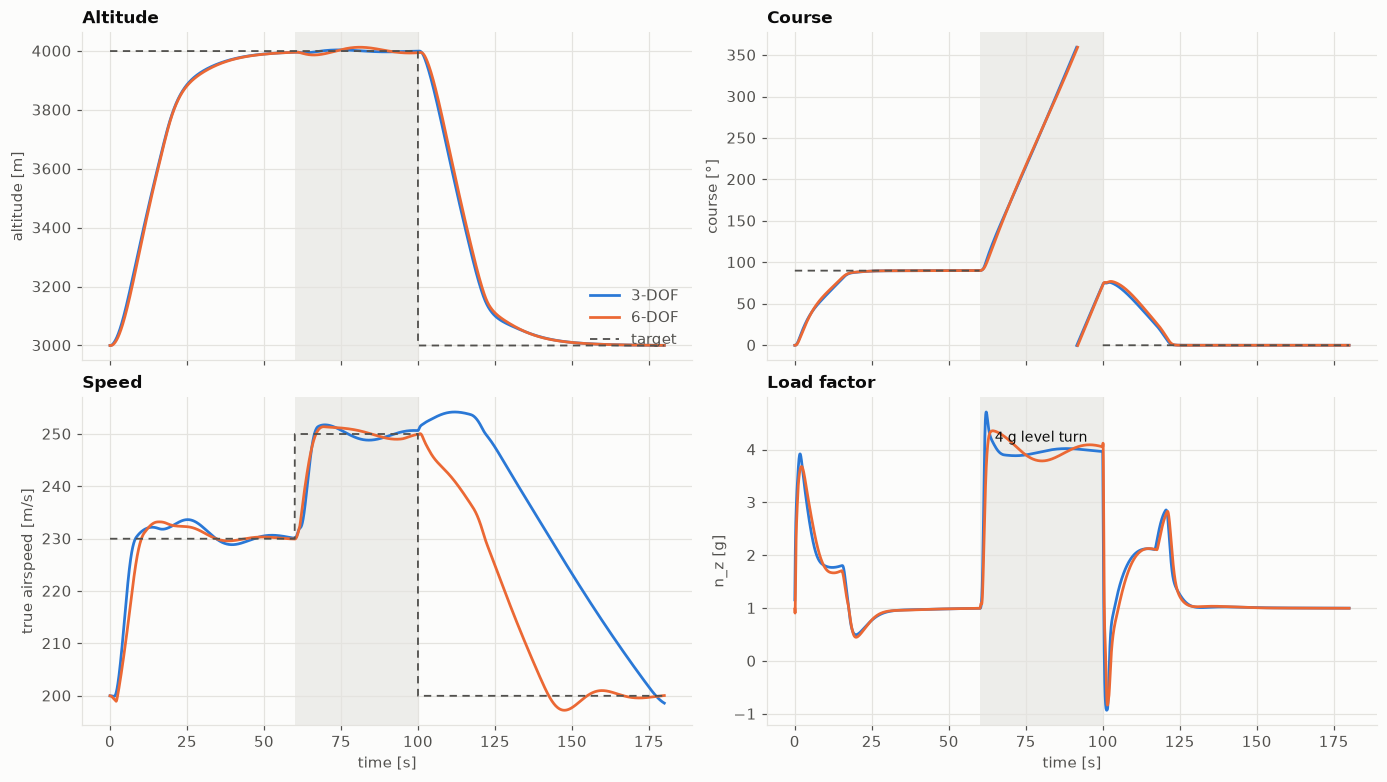

In [5]:
def mission(t):
    if t < 60:
        return AutopilotTargets(altitude=4000, heading=90 * DEG, airspeed=230)
    if t < 100:
        return AutopilotTargets(altitude=4000, bank=math.acos(1 / 4), airspeed=250)
    return AutopilotTargets(altitude=3000, heading=0.0, airspeed=200)


def fly_mission(kind, t_end=180.0):
    if kind == "6-DOF":
        model = d6.F16SixDof(params)
        x, _ = model.trim(3000, 200)
    else:
        model = d3.PointMassAircraft(params)
        x, _ = model.trimmed_state(3000, 200)
    ap = Autopilot(model)
    ins = read_instruments(model, x)
    ap.reset(x, ins)
    t, log = 0.0, []
    while t < t_end:
        ap.targets = mission(t)
        u = ap.controls(ins, DT)
        for _ in range(2):
            x = model.step(x, u)
        t = round(t + DT, 9)
        ins = read_instruments(model, x)
        log.append((t, ins.altitude, math.degrees(ins.course) % 360, ins.tas, ins.nz))
    return np.array(log)


logs = {kind: fly_mission(kind) for kind in ("3-DOF", "6-DOF")}
tt = logs["3-DOF"][:, 0]
targets = [mission(ti) for ti in tt]
target_curves = {
    1: np.array([tg.altitude for tg in targets], float),
    2: np.array([np.nan if tg.heading is None else math.degrees(tg.heading) for tg in targets]),
    3: np.array([tg.airspeed for tg in targets], float),
}

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7), layout="constrained", sharex=True)
titles = {
    1: ("altitude [m]", "Altitude"),
    2: ("course [°]", "Course"),
    3: ("true airspeed [m/s]", "Speed"),
    4: ("n_z [g]", "Load factor"),
}
for ax, col in zip(axes.flat, (1, 2, 3, 4), strict=True):
    for (kind, log), color in zip(logs.items(), SERIES, strict=False):
        y = log[:, col].copy()
        if col == 2:
            y[y > 359.5] -= 360.0  # −0.0° prints as 360°
            y[np.flatnonzero(np.abs(np.diff(y)) > 180) + 1] = np.nan  # break 360 -> 0 jumps
        ax.plot(log[:, 0], y, color=color, label=kind)
    if col in target_curves:
        ax.plot(
            tt,
            target_curves[col],
            color=INK_2,
            linewidth=1.2,
            linestyle=(0, (4, 3)),
            label="target",
        )
    ax.axvspan(60, 100, color=GRID, alpha=0.6, linewidth=0)
    ax.set_ylabel(titles[col][0]), ax.set_title(titles[col][1])
axes[1, 1].text(80, 4.15, "4 g level turn", ha="center", color=INK, fontsize=9)
axes[0, 0].legend(loc="lower right")
for ax in axes[1]:
    ax.set_xlabel("time [s]")
plt.show()

The two very different models fly the mission almost identically in altitude, course and load
factor — a strong consistency check between the 3-DOF and 6-DOF physics (turn rates at 4–5 g
agree within 5 %). The deceleration after the turn differs because the drag models differ (a
fitted polar versus the NASA tables). This agreement is what makes **3-DOF → 6-DOF transfer** of
RL policies plausible in phase 8.

## 4. Optimal control: LQR

As an alternative stabilizer, the **Linear Quadratic Regulator** uses the linearized model of
notebook 3, $\dot{\delta x} = A\,\delta x + B\,\delta u$, and minimizes

$$J = \int_0^\infty \left(\delta x^T Q\,\delta x + \delta u^T R\,\delta u\right) dt$$

The optimal control is a state feedback $\delta u = -K\,\delta x$ with $K = R^{-1}B^T S$, where
$S$ solves the algebraic Riccati equation $A^T S + S A - S B R^{-1} B^T S + Q = 0$
(`scipy.linalg.solve_continuous_are`). Designed on the longitudinal states $[V, \alpha, \theta, q]$
with the elevator only, at the **unstable** CG:

K = [[ 0.009 -0.387 -0.529 -0.409]]  (gains on V, α, θ, q)


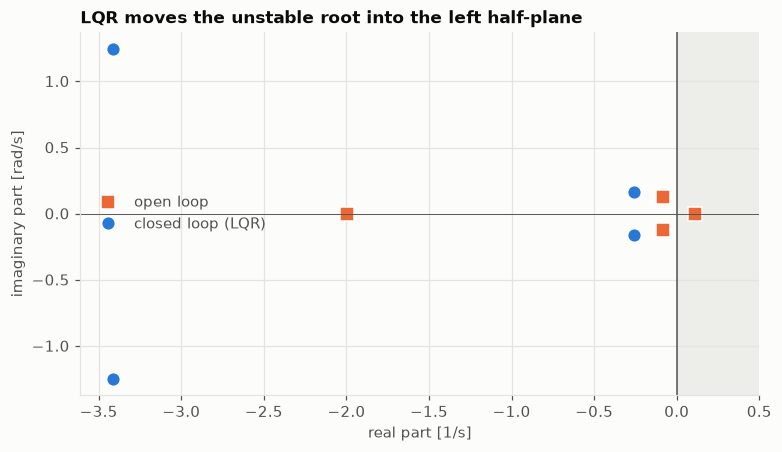

In [6]:
lqr_model = d6.F16SixDof(params, xcg=0.35)
lqr = LongitudinalLQR.design(lqr_model, 3000, 200)
print("K =", np.round(lqr.K, 3), " (gains on V, α, θ, q)")
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
for eig, color, marker, label in (
    (lqr.open_loop, SERIES[1], "s", "open loop"),
    (lqr.closed_loop, SERIES[0], "o", "closed loop (LQR)"),
):
    ax.plot(
        eig.real, eig.imag, marker, color=color, markersize=9, markeredgecolor="white", label=label
    )
ax.axvline(0, color=INK_2, linewidth=1)
ax.axhline(0, color=INK_2, linewidth=0.6)
ax.axvspan(0, 0.5, color=GRID, alpha=0.6, linewidth=0)
ax.set_xlim(right=0.5)
ax.set_xlabel("real part [1/s]"), ax.set_ylabel("imaginary part [rad/s]")
ax.set_title("LQR moves the unstable root into the left half-plane")
ax.legend(loc="center left")
plt.show()

LQR is elegant and optimal — but only **around its design point**. The FBW above, with gain
scheduling and limiters, is what actually flies the whole envelope; LQR stays in the project as
a reference for comparison.

## 5. Scripted evasion primitives (for phase 10)

The last baseline anticipates missile evasion: classic geometric maneuvers that the RL agent
will be compared against. Given the threat's bearing:

* **beam**: fly perpendicular to the line of sight — the closing speed drops, which confuses
  Doppler seekers and forces the missile to turn;
* **drag**: turn tail to the threat — lengthen the chase and let the missile burn its energy;
* **break turn**: max-g turn toward the threat at the last moment.

In [7]:
heading = 0.0
for threat in (30, 120, -150):
    b = threat * DEG
    print(
        f"threat at bearing {threat:>4}°, own heading 000° -> beam heading "
        f"{math.degrees(maneuvers.beam_heading(b, heading)) % 360:5.0f}°, drag heading "
        f"{math.degrees(maneuvers.drag_heading(b)) % 360:5.0f}°"
    )

threat at bearing   30°, own heading 000° -> beam heading   300°, drag heading   210°
threat at bearing  120°, own heading 000° -> beam heading    30°, drag heading   300°
threat at bearing -150°, own heading 000° -> beam heading   300°, drag heading    30°


## Takeaways

* A disciplined **PID** (anti-windup, derivative on measurement, bumpless transfer) is the
  workhorse; **gain scheduling** on dynamic pressure makes one set of gains work everywhere.
* The **fly-by-wire** loop stabilizes even the unstable F-16 and protects the structure
  (n_z and α limiters) — it defines the *hierarchical action space* of the RL agent.
* The **autopilot** flies the same mission on both models with the same gains: it is the
  reference every RL agent is measured against.
* **LQR** provides an optimal local stabilizer and a textbook comparison.

A lesson learned here: the angle to control in a turn is the **lift-vector bank μ**, not the
fuselage roll φ (notebook 4) — the difference made tight turns fail.

**Next:** the [jetfighter-rl](https://github.com/elouansalaun/jetfighter-rl) repository wraps all this into a Gymnasium environment ([notebook 7](https://github.com/elouansalaun/jetfighter-rl/blob/main/notebooks/07_gym_environment.ipynb)) and trains agents on it.